## Imports

In [169]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas_ta as ta
from sklearn.preprocessing import StandardScaler
from pykalman import KalmanFilter
import hmmlearn.hmm as hmm
from hmmlearn.hmm import GaussianHMM
import random
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings 

warnings.filterwarnings("ignore")




## Get asset candle data

In [170]:

asset = "bitcoin"

# Load asset data
df_1 = pd.read_csv(f"micro/candleData/{asset}_candles.csv")
df_1['date'] = pd.to_datetime(df_1['date'])
df_1.set_index('date', inplace=True)

df_2 = pd.read_csv(f"micro/assetData/{asset}.csv")
df_2['date'] = pd.to_datetime(df_2['date'])
df_2.set_index('date', inplace=True)

data = pd.merge(df_1, df_2[['total_volume']], left_index=True, right_index=True, how='inner')

data.rename(columns={'total_volume': 'Volume',
                     'open': 'Open',
                     'high': 'High',
                     'low': 'Low',
                     'close': 'Close'}, inplace=True)

# Print final data quality check
print("\nFinal Dataset Shape:", data.shape)
print("\nMissing Values in Final Dataset:")
print(data.isnull().sum())

data.index.name = 'Date'

data


Final Dataset Shape: (4312, 5)

Missing Values in Final Dataset:
Open      2
High      2
Low       2
Close     2
Volume    0
dtype: int64


,Open,High,Low,Close,Volume
Date,,,,,
2013-04-27,NaN,NaN,NaN,NaN,0.000000e+00
2013-04-28,NaN,NaN,NaN,NaN,0.000000e+00
2013-04-29,135.30,135.30,135.30,135.30,0.000000e+00
2013-04-30,141.96,141.96,141.96,141.96,0.000000e+00
2013-05-01,135.30,135.30,135.30,135.30,0.000000e+00
...,...,...,...,...,...
2025-02-12,97465.00,98467.00,94899.00,95740.00,4.711562e+10
2025-02-13,95743.00,98098.00,94120.00,97836.00,2.908437e+10
2025-02-14,97887.00,98089.00,95410.00,96562.00,3.228991e+10


## Calculate features

#### Plot feature distributions

In [171]:
def plot_feature_distributions(df, feature_cols=None, bins=50, figsize=(15, 10)):
    """
    Plots the distribution (histograms) of specified feature columns in a DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing your features.
    feature_cols : list of str, optional
        List of columns to plot. If None, attempts to plot all numeric columns 
        except non-feature columns (e.g., 'symbol', 'interval', 'Date').
    bins : int, optional
        Number of histogram bins. Default 50.
    figsize : tuple, optional
        Figure size for the overall plot. Default (15, 10).
    
    Returns
    -------
    None (Displays a Matplotlib figure of histograms)
    """
    
    # If user does not specify feature columns, attempt to infer from numeric columns
    if feature_cols is None:
        # Exclude any known non-feature columns
        exclude_cols = {'symbol', 'interval', 'Date'}
        feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                        if col not in exclude_cols]
    
    n_features = len(feature_cols)
    
    # Decide on subplot grid (approx square layout)
    n_cols = int(np.ceil(np.sqrt(n_features)))
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()  # Flatten to easily iterate even if there's only 1 row
    
    for i, col in enumerate(feature_cols):
        ax = axes[i]
        # Drop NaN to avoid issues in hist
        valid_data = df[col].dropna()
        ax.hist(valid_data, bins=bins, edgecolor='k', alpha=0.7)
        ax.set_title(col)
        ax.set_ylabel('Count')
        ax.set_xlabel('Value')
        ax.grid(True, linestyle='--', alpha=0.5)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

#### Generate and normalize features

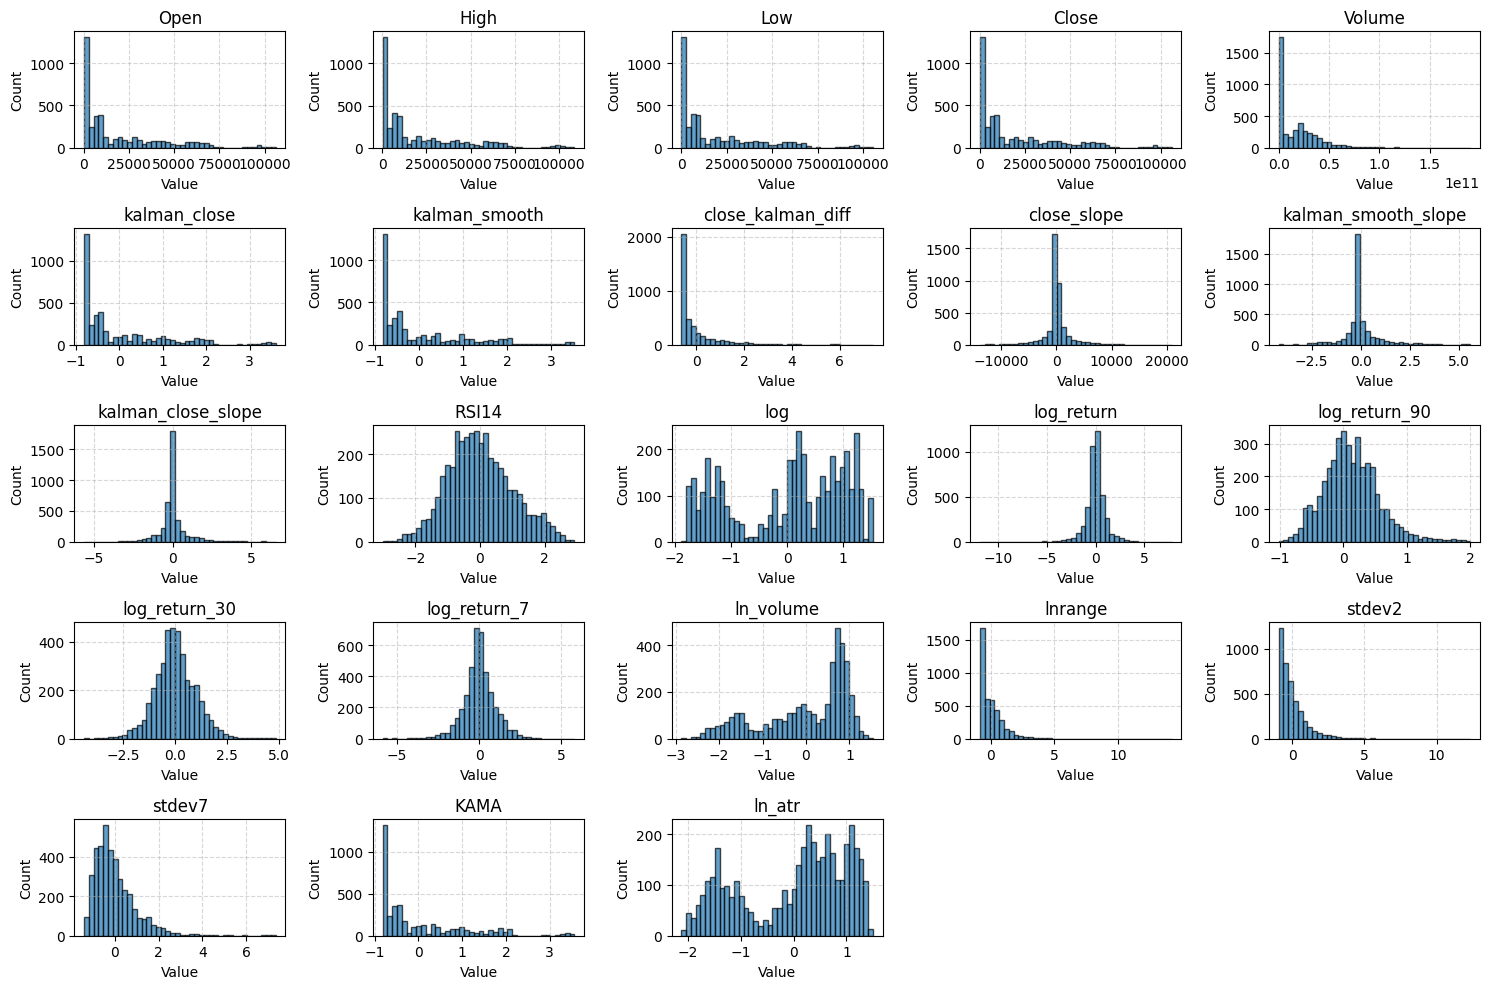

In [172]:

def kama(series, n=10, fast=2, slow=30):
    """
    Calculate the Kaufman Adaptive Moving Average (KAMA) for a given price series.

    Parameters:
    -----------
    series : pd.Series
        Price series (e.g., Close prices).
    n : int, optional
        Number of periods to use for the efficiency ratio. Default is 10.
    fast : int, optional
        The period for the fastest allowable EMA. Default is 2.
    slow : int, optional
        The period for the slowest allowable EMA. Default is 30.

    Returns:
    --------
    pd.Series
        A Series containing the computed KAMA values.
    """

    # Calculate the Efficiency Ratio (ER)
    change = series.diff(n).abs()
    volatility = series.diff().abs().rolling(n).sum()
    er = change / volatility
    er = er.fillna(0)

    # Calculate the smoothing constant (SC)
    fast_sc = 2 / (fast + 1)
    slow_sc = 2 / (slow + 1)
    sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2

    # Allocate an array for KAMA values and initialize with NaNs.
    kama_values = pd.Series(np.nan, index=series.index)
    # Set the first valid KAMA value equal to the price at the n-th index.
    if len(series) > n:
        kama_values.iloc[n] = series.iloc[n]
    
    # Recursively compute KAMA starting from the (n+1)-th element.
    for i in range(n + 1, len(series)):
        kama_values.iloc[i] = kama_values.iloc[i - 1] + sc.iloc[i] * (series.iloc[i] - kama_values.iloc[i - 1])
    
    return kama_values

def calculate_atr(high, low, close, window=14):
    """
    Calculate the Average True Range (ATR).

    ATR is defined as the rolling average (window=14 by default) of the True Range.
    True Range (TR) is the maximum of:
      - (High - Low)
      - Absolute(High - previous Close)
      - Absolute(Low - previous Close)
    """
    prev_close = close.shift(1)
    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(window=window, min_periods=window).mean()
    return atr

# Setup Kalman Filter (make sure data is loaded before setting initial_state_mean)
kf = KalmanFilter(
    transition_matrices=[1],
    observation_matrices=[1],
    initial_state_mean=None,  # will be set after loading data
    initial_state_covariance=1,
    observation_covariance=1,
    transition_covariance=0.01
)

# Assume 'data' has already been loaded and merged with macro data.
df = data.copy()
df.dropna(inplace=True)

# Apply the Kalman filter on Close prices
kf.initial_state_mean = df['Close'].iloc[0]
state_means, state_covariances = kf.filter(df['Close'].values)
df['kalman_close'] = state_means.flatten()
smoothed_state_means, smoothed_state_covariances = kf.smooth(df['kalman_close'].values)
df['kalman_smooth'] = smoothed_state_means.flatten()
df['close_kalman_diff'] = np.abs(df['Close'] - df['kalman_smooth'])
df['close_slope'] = df['Close'].diff(periods=7)
df['kalman_smooth_slope'] = df['kalman_smooth'].diff(periods=7)
df['kalman_close_slope'] = df['kalman_close'].diff(periods=7)
# Compute technical indicators
df['RSI14'] = ta.rsi(df['Close'], length=14)

# Handle potential infinities in log calculations
df['log'] = np.log(df['Close'].replace(0, np.nan))
df['log_return'] = df['log'].diff()
df['log_return_90'] = df['log'].diff(periods=90)
df['log_return_30'] = df['log'].diff(periods=30)
df['log_return_7'] = df['log'].diff(periods=7)
df['ln_volume'] = np.log(df['Volume'].replace(0, np.nan) + 1)  # Add 1 to avoid log(0)
df['lnrange'] = np.log((df['High'] / df['Low']).replace([np.inf, -np.inf], np.nan))
df['stdev2'] = df['log_return'].rolling(window=2).std()
df['stdev7'] = df['log_return'].rolling(window=7).std()
# Calculate ATR and handle potential infinities
df['KAMA'] = kama(df['Close'], n=10, fast=2, slow=30)
df['ln_atr'] = np.log(calculate_atr(df['High'], df['Low'], df['Close'], window=14).replace(0, np.nan))

# Drop rows with any NaN values (this will remove the early rows affected by rolling calculations)
df.dropna(inplace=True)

# Replace any remaining infinities with NaN and drop those rows
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Scale features
scaler = StandardScaler()

features_to_scale = [
    'log', 'log_return', 'lnrange',
    'RSI14', 'log_return_30', 'log_return_7', 'ln_atr',
    'kalman_close', 'kalman_smooth', 'kalman_smooth_slope', 'kalman_close_slope', 
    'close_kalman_diff', 'ln_volume', 'stdev2','stdev7', 'KAMA'
]

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# Add symbol and interval columns
#symbol = 'BTC'
#interval = '1D'
#df.insert(0, 'symbol', symbol.upper())
#df.insert(1, 'interval', interval.upper())

plot_feature_distributions(df, feature_cols=df.columns, bins=40)

## Test and Train splitting

#### Split functions

In [173]:
def split_date_wise(data, 
                    embargo_percent=0.01, 
                    train_start_date=None,
                    train_end_date=None):
    
    #throw error if data in improper form
    if isinstance(data, pd.DataFrame) == False or 'Date' not in data:
        raise ValueError("""Data must be of type pd.DataFrame and contain a 
                         'date' column.""")
       
    #handle no dates given
    if train_start_date == None and train_end_date == None:
        raise ValueError("""At least one of train_start_date and 
                         train_end_date params must be given an argument.""")
 
    #handle end date given but no start
    if train_end_date != None and train_start_date == None:
        train_start_date = data['Date'][0]
 
    #handle start date given but no end
    if train_start_date != None and train_end_date == None:
        raise ValueError('end_date must be given.')
     
    #find start index
    #consider forcing start date to nearest trade day if non-trading day given
    start_index = -1
    for i in range(len(data)):    
        if data['Date'][i] == pd.to_datetime(train_start_date):
            start_index = i 
    
    #raise error if day train_start_date not in data
    if start_index < 0:
        raise ValueError('train_start_date of: ' + train_start_date + 
                         ' not in data.'
                         +' Make sure given date is trading day.')
    
    #find end index
    end_index = -1
    for i in range(len(data)):
        if data['Date'][i] == pd.to_datetime(train_end_date):
            end_index = i
    
    #throw error if day train_start_date not in data
    if end_index < 0:
        raise ValueError(
            'train_end_date of: ' + train_end_date + ' not in data.'
                         +' Make sure given date is trading day.')
    
    #set train, test and embargo set    
    train = data[start_index:end_index+1]
    test = data[round((end_index+1)+(embargo_percent*len(data))):]
    embargo = data[end_index+1:round(end_index+(embargo_percent*len(data))+1)]
    
    #throw error if test set empty
    if len(test) == 0:
        raise ValueError(
            'No data in test set, reduce embargo size or date range.')
    
    #warn if embargo length short
    if len(embargo) < 5:
        import warnings
        warnings.warn("""<5 embargoed data points means data the model was
                      trained on is likely to leak into test set.""")
      
    return train, embargo, test

def split_rand(data, train_percent):

    train = data[np.random.rand(len(data)) < 0.8]
    test = data[~np.random.rand(len(data)) < 0.8]
    
    return train, test

## Generate splits

`Some assets won't have enough data, so we'll use only Kalman filter `

In [174]:
df.reset_index(inplace=True)
train, embargo, test = split_date_wise(df,
                                     embargo_percent=0.01,
                                     train_start_date=df['Date'][0],
                                     train_end_date='2023-12-31')

## HMM Model

In [175]:

# Set random seeds for reproducibility
np.random.seed(4214609)  # for numpy operations
random.seed(4214609)     # for Python's random module

# ln vor btc has bad results du to dirty data at the beginning, shallow liquidity

features_btc = ['Date', 'log_return', 'log_return_30', 'log_return_7', 'RSI14', 'ln_atr', 'kalman_smooth_slope'] 

features_alts = ['Date', 'kalman_smooth_slope', 'ln_atr', 'log_return_30', 'RSI14', 'ln_volume']


#set features
f_train = train[features_btc if asset == "bitcoin" else features_alts].set_index('Date')

f_test = test[features_btc if asset == "bitcoin" else features_alts].set_index('Date')

hmm = GaussianHMM(n_components=4, 
                  covariance_type="full", n_iter=100000000, verbose=False).fit(f_train)
 
#predict hidden states on test set
hidden_states = hmm.predict(f_test)


In [176]:
def generate_hmm_states(hmm, test, f_test):
    """
    Generates HMM state series and state probability DataFrame for a 4-state model.
    The 4 states are designed to capture bull/bear regimes with high/low volatility.

    For each state i in {0,1,2,3}:
      - Compute the mean return (using the first dimension of hmm.means_[i])
      - Compute volatility as sqrt(first diagonal element of hmm.covars_[i])
      - Assign regime: 'Bull' if mean > 0, else 'Bear'
    
    Then, for each regime, the state with lower volatility is labeled '_Lo' and the one with higher volatility as '_Hi'.
    The resulting state labels will be:
        'Bull_Lo', 'Bull_Hi', 'Bear_Lo', 'Bear_Hi'
    
    Additionally, this function computes state probabilities and aggregates them into bull vs. bear probabilities.

    Returns:
      hmm_state_series: A copy of the 'test' DataFrame with added columns:
         - 'hidden_state': The integer state assigned by the HMM.
         - 'state': The regime label (e.g. 'Bull_Lo', etc.).
         - 'return': The percentage change of the 'log' column.
      p_of_states: A DataFrame with index matching f_test and columns:
         - 'bull_prob': Sum of probabilities for states whose label starts with 'Bull'
         - 'bear_prob': 1 - bull_prob
    """

    # Predict hidden states for the test set using f_test features.
    hidden_states = hmm.predict(f_test)
    
    # Compute mean and volatility for each state.
    state_info = []
    for i in range(4):
        # Use the first dimension (e.g., mean log return)
        mean_i = hmm.means_[i][0]
        # Compute volatility from the first diagonal element of the covariance matrix.
        vol_i = np.sqrt(np.diag(hmm.covars_[i])[0])
        regime = 'Bull' if mean_i > 0 else 'Bear'
        state_info.append({'state_num': i, 'mean': mean_i, 'vol': vol_i, 'regime': regime})
    
    # For each regime, assign 'Lo' to the state with lower volatility and 'Hi' to the other.
    for regime in ['Bull', 'Bear']:
        states_in_regime = [s for s in state_info if s['regime'] == regime]
        if len(states_in_regime) >= 2:
            states_in_regime_sorted = sorted(states_in_regime, key=lambda s: s['vol'])
            states_in_regime_sorted[0]['label'] = f'{regime}_Lo'
            states_in_regime_sorted[1]['label'] = f'{regime}_Hi'
        elif len(states_in_regime) == 1:
            # If only one exists, simply assign the regime label.
            states_in_regime[0]['label'] = regime

    # Create a mapping from state number to its label.
    state_label_map = {s['state_num']: s.get('label', s['regime']) for s in state_info}
    
    # Build the HMM state series DataFrame.
    hmm_state_series = test.copy()
    hmm_state_series['hidden_state'] = hidden_states
    hmm_state_series['state'] = hmm_state_series['hidden_state'].map(state_label_map)
    hmm_state_series['return'] = hmm_state_series['log'].pct_change()
    
    # Create a DataFrame for state probabilities.
    p_of_states = pd.DataFrame(
        hmm.predict_proba(f_test),
        index=f_test.index,
        columns=[f'state_{i}' for i in range(4)]
    )
    # Sum probabilities for states labeled as 'Bull'.
    bull_states = [i for i, lbl in state_label_map.items() if lbl.startswith('Bull')]
    bull_prob = p_of_states[[f'state_{i}' for i in bull_states]].sum(axis=1)
    p_of_states_probs = pd.DataFrame({
        'bull_prob': bull_prob,
        'bear_prob': 1 - bull_prob
    })

    return hmm_state_series, p_of_states_probs

array([[<Axes: title={'center': 'bull_prob'}>,
        <Axes: title={'center': 'bear_prob'}>]], dtype=object)

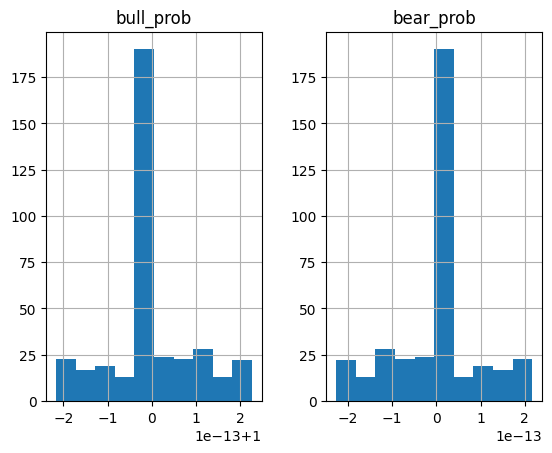

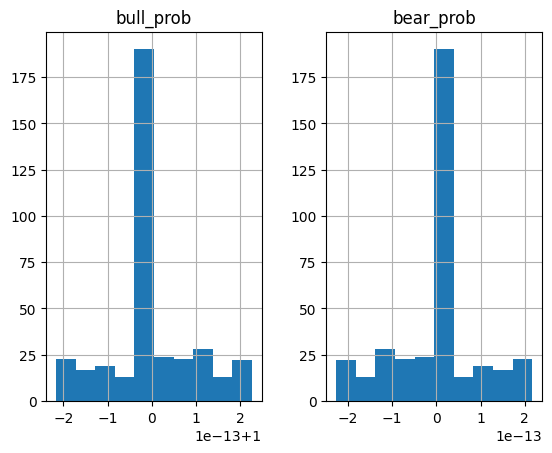

In [177]:
hmm_state_series_long_short, p_of_states_fav_unfav_long_short = generate_hmm_states(hmm, test, f_test)
hmm_state_series_long_only, p_of_states_fav_unfav_long_only = generate_hmm_states(hmm, test, f_test)
p_of_states_fav_unfav_long_short.hist()
p_of_states_fav_unfav_long_only.hist()

## Generate trading signals

In [178]:
def transact_at_open(test, hmm_state_series, p_of_states):
       """
       Creates trading signals based on 4-state HMM outputs and calculates strategy returns.
       """

       
       # Start with a copy of the test DataFrame.
       df = test.copy()
       
       # Ensure the p_of_states DataFrame is aligned with test.
       p_of_states.index = test.index
       
       # Merge HMM state information into the test DataFrame.
       df = df.join(hmm_state_series[['hidden_state', 'state']])
       
       # Use bear_prob from p_of_states as "unfav"
       df = df.join(p_of_states[['bear_prob']])
       df.rename(columns={'bear_prob': 'unfav'}, inplace=True)
       
       # Map state labels to positions.
       state_mapping = {
           'Bull_Lo': 1.0,
           'Bull_Hi': 1,
           'Bear_Lo': 0,
           'Bear_Hi': -0.5
       }
       df['raw_position'] = df['state'].map(state_mapping).fillna(0)
       
       # Shift for trade simulation.
       df['signal'] = df['raw_position'].shift(1)
       
       # Calculate returns.
       df['next_open'] = df['Open'].shift(-1)
       df['open_return'] = (df['next_open'] / df['Open']) - 1
       df['open_return'] = df['open_return'].fillna(0)
       df['strategy_return'] = df['signal'] * df['open_return']
       
       # Mark trades.
       df['trade'] = (df['signal'] != df['signal'].shift(1)).astype(int)
       
       # Cumulative returns.
       df['cum_strategy_return'] = (1 + df['strategy_return']).cumprod() - 1
       df['cum_buy_hold_return'] = (1 + df['open_return']).cumprod() - 1
       
       return df  # Make sure this is present!

In [179]:
long_short = transact_at_open(test, hmm_state_series_long_short, p_of_states_fav_unfav_long_short)
long_only = transact_at_open(test, hmm_state_series_long_only, p_of_states_fav_unfav_long_only)


### Plot strategy results

In [180]:
def plot_hmm_results(df):
    """
    Given a DataFrame (such as that returned by transact_at_open()) that includes:
      - Date (as a column)
      - 'hidden_state': the raw state from the HMM (e.g. 0, 1, or 2)
      - 'cum_buy_hold_return': cumulative return from buying and holding the asset
      - 'cum_strategy_return': cumulative return from the HMM-based strategy
      - 'unfav': the probability that the state is unfavored
    this function produces a two-panel interactive Plotly plot and backtest metrics.
    """
    
    # Ensure Date is datetime
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    
    # Calculate backtest metrics
    def calculate_metrics(returns, cum_returns, is_strategy=True, df=None):
        total_return = cum_returns.iloc[-1]
        
        # Annualized return (assuming daily data)
        days = (df['Date'].iloc[-1] - df['Date'].iloc[0]).days
        ann_return = ((1 + total_return) ** (365/days)) - 1
        
        if is_strategy:
            # Count state changes (excluding changes to/from flat)
            state_changes = df['raw_position'].diff().fillna(0)
            trades = (state_changes != 0).sum()
            
            # Calculate win rate based on daily returns during active positions
            active_returns = returns[df['raw_position'] != 0]
            win_rate = (active_returns > 0).sum() / len(active_returns) if len(active_returns) > 0 else 0
        else:
            # Buy & hold has no trades
            trades = 0
            win_rate = 0
        
        # Drawdown calculations
        wealth_index = 1 + cum_returns
        previous_peaks = wealth_index.expanding(min_periods=1).max()
        drawdowns = (wealth_index - previous_peaks) / previous_peaks
        max_drawdown = drawdowns.min()
        
        # Sharpe ratio (assuming daily data)
        risk_free_rate = 0.02  # 2% annual risk-free rate
        daily_rf = (1 + risk_free_rate) ** (1/365) - 1
        excess_returns = returns - daily_rf
        sharpe = np.sqrt(365) * (excess_returns.mean() / returns.std())
        
        return {
            'Total Return': f'{total_return:.2%}',
            'Annualized Return': f'{ann_return:.2%}',
            'Number of Trades': trades,
            'Max Drawdown': f'{max_drawdown:.2%}',
            'Sharpe Ratio': f'{sharpe:.2f}',
            'Win Rate': f'{win_rate:.2%}'
        }
    
    # Calculate metrics for both strategy and buy & hold
    strategy_metrics = calculate_metrics(df['strategy_return'], 
                                      df['cum_strategy_return'], 
                                      is_strategy=True, 
                                      df=df)
    
    bh_metrics = calculate_metrics(df['open_return'], 
                                 df['cum_buy_hold_return'], 
                                 is_strategy=False,
                                 df=df)  # Added df parameter here

    # Create metrics table
    metrics_table = pd.DataFrame({
        'Strategy': strategy_metrics,
        'Buy & Hold': bh_metrics
    }).round(4)
    
    # Create figure with three rows (added space for table)
    fig = make_subplots(
        rows=3, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.1,
        row_heights=[0.5, 0.2, 0.3],
        specs=[[{"type": "scatter"}],
               [{"type": "table"}],
               [{"type": "scatter"}]]
    )

    # Top Panel: Returns
    fig.add_trace(
        go.Scatter(
            x=df['Date'],
            y=df['cum_buy_hold_return'],
            mode='markers',
            name='Buy & Hold',
            marker=dict(
                size=3,
                color=df['hidden_state'],
                colorscale='Viridis',
                showscale=True,
                colorbar=dict(title='Hidden State')
            )
        ),
        row=1, col=1
    )
    
    fig.add_trace(
        go.Scatter(
            x=df['Date'],
            y=df['cum_strategy_return'],
            mode='lines',
            name='HMM Strategy',
            line=dict(color='red', width=2)
        ),
        row=1, col=1
    )
    
    # Middle Panel: Metrics Table
    fig.add_trace(
        go.Table(
            header=dict(
                values=['Metric', 'Strategy', 'Buy & Hold'],
                font=dict(size=12),
                align="left"
            ),
            cells=dict(
                values=[metrics_table.index, 
                        metrics_table['Strategy'],
                        metrics_table['Buy & Hold']],
                font=dict(size=11),
                align="left"
            )
        ),
        row=2, col=1
    )
    
    # Bottom Panel: Unfavored Probability
    fig.add_trace(
        go.Scatter(
            x=df['Date'],
            y=df['unfav'],
            mode='lines',
            name='Unfavored Probability',
            line=dict(color='black', width=2)
        ),
        row=3, col=1
    )
    
    # Update layout
    fig.update_layout(
        title='HMM-Regime Based Strategy Analysis',
        template='plotly_white',
        height=1000,  # Increased height to accommodate table
        showlegend=True,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )
    
    # Update y-axes labels
    fig.update_yaxes(title_text="Cumulative Return", row=1, col=1)
    fig.update_yaxes(title_text="Unfavored Probability", row=3, col=1)
    
    # Update x-axis label
    fig.update_xaxes(title_text="Date", row=3, col=1)
    
    # Show the plot
    fig.show()

In [181]:
plot_hmm_results(long_only)
plot_hmm_results(long_short)